# Run the corridor-processing workflow

This notebook loads the functions from `corridor_processing_notebook_block.py`, applies them to an original binary topography image, and exports the processing schematic and CSV files.

Place this notebook and `corridor_processing_notebook_block.py` in the same folder, or update `SCRIPT_PATH` below.

In [3]:
from pathlib import Path

# -------------------------------------------------------------------------
# FILES
# -------------------------------------------------------------------------

SCRIPT_PATH = Path("corridor_processing_notebook_block.py")

# Use a TIFF/PNG path:
INPUT_IMAGE = Path(r"..\FixedPattern_16x16_1462_binary_filled.tif")

# Alternatively, if the image is already loaded as a NumPy array called img:
# INPUT_IMAGE = img

# -------------------------------------------------------------------------
# SURFACE SETTINGS
# -------------------------------------------------------------------------

SURFACE = 1462

SURFACE_SETTINGS = {
    1462: {
        "surface_name": "TopoChip feature 1462",
        "rotation_deg": 28.34,
    },
    1476: {
        "surface_name": "TopoChip feature 1476",
        "rotation_deg": -13.47,
    },
}

SURFACE_NAME = SURFACE_SETTINGS[SURFACE]["surface_name"]
ROTATION_DEG = SURFACE_SETTINGS[SURFACE]["rotation_deg"]

PIXEL_SIZE_UM = 0.56
COVERAGE_THRESHOLD = 0.07
MIN_ACCESSIBLE_AREA = 16
MAX_FILLED_HOLE_AREA = 64
ROW_KERNEL_SIZE = 3
MIN_BAND_HEIGHT = 5

# Set a normalized threshold between 0 and 1 only when automatic thresholding
# gives the wrong image polarity. Otherwise leave this as None.
MANUAL_THRESHOLD = None

# None selects the corridor nearest the vertical image centre.
SELECTED_CORRIDOR_ID = None

OUTPUT_DIR = Path(f"corridor_processing_output_{SURFACE}")
SAVE_PDF = True

print(f"Surface: {SURFACE_NAME}")
print(f"Rotation: {ROTATION_DEG:+.2f} degrees")
print(f"Output folder: {OUTPUT_DIR.resolve()}")

Surface: TopoChip feature 1462
Rotation: +28.34 degrees
Output folder: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\corridor_processing_output_1462


## Load the processing functions

The original Python file contains a settings section and a final run section.  
This cell loads its function definitions without executing the file's hard-coded example run.

In [4]:
if not SCRIPT_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the processing file:\n{SCRIPT_PATH.resolve()}\n\n"
        "Place corridor_processing_notebook_block.py beside this notebook "
        "or update SCRIPT_PATH."
    )

source = SCRIPT_PATH.read_text(encoding="utf-8")

run_marker = (
    "# =============================================================================\n"
    "# RUN\n"
    "# ============================================================================="
)

if run_marker not in source:
    raise RuntimeError(
        "The expected RUN marker was not found in the processing file. "
        "Check that SCRIPT_PATH points to corridor_processing_notebook_block.py."
    )

definitions_only = source.split(run_marker, 1)[0]

processing_namespace = {
    "__name__": "corridor_processing_functions",
    "__file__": str(SCRIPT_PATH.resolve()),
}

exec(
    compile(definitions_only, str(SCRIPT_PATH.resolve()), "exec"),
    processing_namespace,
)

process_corridors = processing_namespace["process_corridors"]
create_processing_schematic = processing_namespace["create_processing_schematic"]

print("Processing functions loaded successfully.")

Processing functions loaded successfully.


## Run the processing workflow

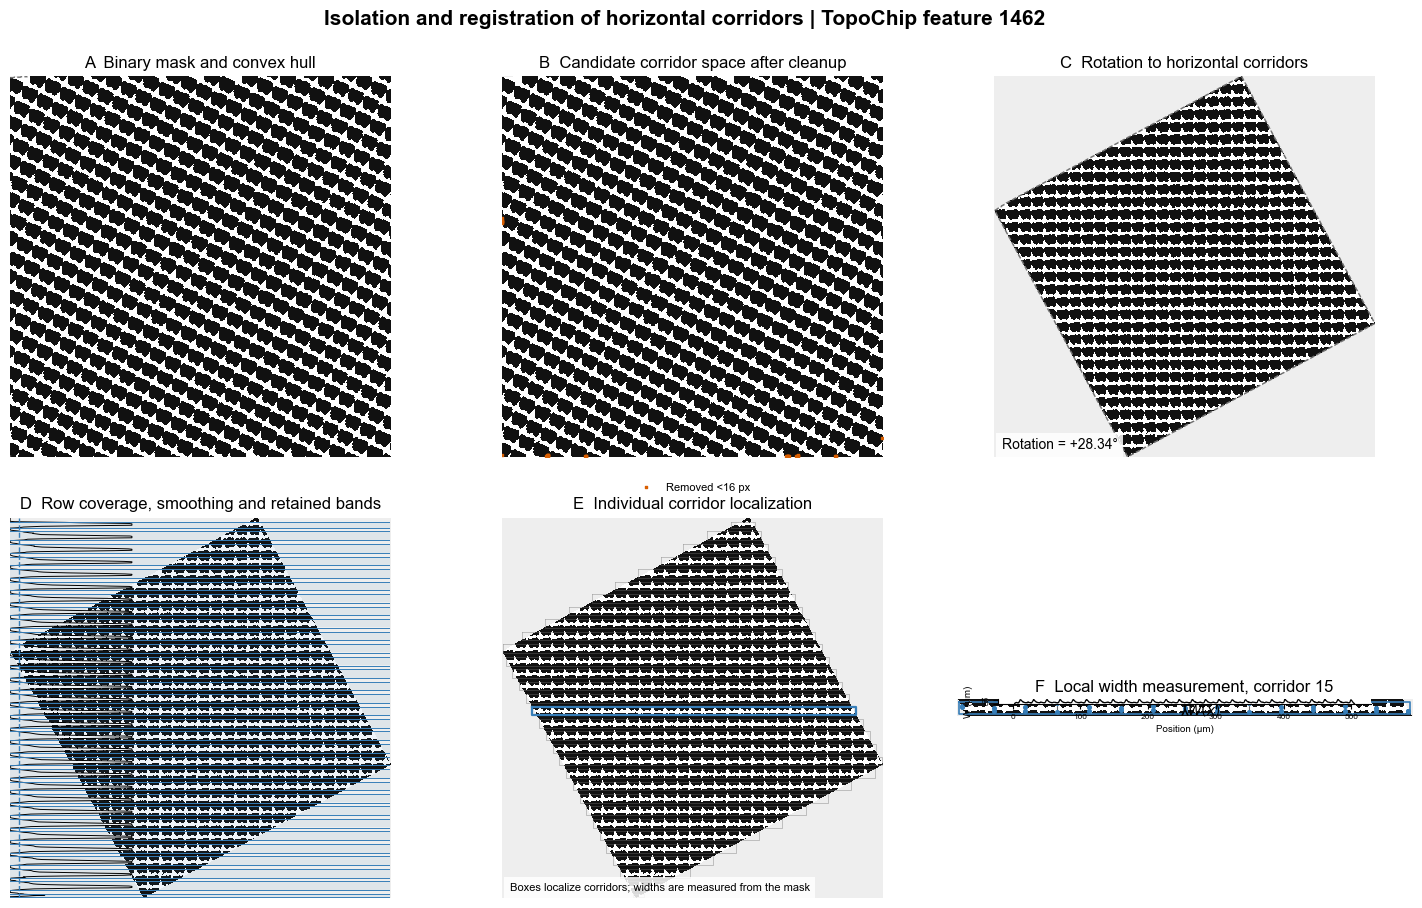

Detected corridors: 31
Selected corridor in panel F: 15
Binary threshold: 0.5000
Saved figure: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\corridor_processing_output_1462\corridor_processing_schematic.png


In [5]:
result = process_corridors(
    image_or_path=INPUT_IMAGE,
    rotation_deg=ROTATION_DEG,
    pixel_size_um=PIXEL_SIZE_UM,
    coverage_threshold=COVERAGE_THRESHOLD,
    min_accessible_area=MIN_ACCESSIBLE_AREA,
    max_filled_hole_area=MAX_FILLED_HOLE_AREA,
    row_kernel_size=ROW_KERNEL_SIZE,
    min_band_height=MIN_BAND_HEIGHT,
    manual_threshold=MANUAL_THRESHOLD,
)

create_processing_schematic(
    result=result,
    surface_name=SURFACE_NAME,
    rotation_deg=ROTATION_DEG,
    pixel_size_um=PIXEL_SIZE_UM,
    coverage_threshold=COVERAGE_THRESHOLD,
    output_dir=OUTPUT_DIR,
    selected_corridor_id=SELECTED_CORRIDOR_ID,
    save_pdf=SAVE_PDF,
)

## Inspect the detected corridors

In [ ]:
display(result["corridors"])

print(f"Number of detected corridors: {len(result['corridors'])}")
print(f"Figure: {(OUTPUT_DIR / 'corridor_processing_schematic.png').resolve()}")
print(f"Boxes: {(OUTPUT_DIR / 'corridor_bounding_boxes.csv').resolve()}")
print(f"Profiles: {(OUTPUT_DIR / 'corridor_width_profiles.csv').resolve()}")

## Display the saved schematic

In [ ]:
from IPython.display import Image, display

figure_path = OUTPUT_DIR / "corridor_processing_schematic.png"

if not figure_path.exists():
    raise FileNotFoundError(f"The expected figure was not created: {figure_path.resolve()}")

display(Image(filename=str(figure_path)))

## Optional: inspect one corridor-width profile

Change `CORRIDOR_TO_PLOT` to any ID listed in the corridor table.

In [ ]:
import matplotlib.pyplot as plt

CORRIDOR_TO_PLOT = int(result["corridors"].iloc[len(result["corridors"]) // 2]["corridor_id"])
profile = result["profiles"][CORRIDOR_TO_PLOT]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(profile["x_um"], profile["width_um"], linewidth=1)
ax.set_xlabel("Position along corridor (µm)")
ax.set_ylabel("Local confinement width, W(x) (µm)")
ax.set_title(f"{SURFACE_NAME}, corridor {CORRIDOR_TO_PLOT}")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()